## **Table of Contents**

1. [Introduction](#1-introduction)

2. [Install and import libraries](#2-install-and-import-libraries)

3. [Dataset preprocess](#3-dataset-preprocess)

4. [Dataset exploration](#4-dataset-exploration)


## 1. Introduction
This project aims to explore the possibilities of building a fake news classifier with very little labeled data. Traditional supervised learning methods require large amounts of labeled data, consisting of both - real and fake news. Building and maintaining fully annotated datasets can be expensive, require large amounts of human labor, or can be simply infeasible, because new forms of misinformation evolve quickly. To address this limitations, the project adopts a Positive-Unlabled learning framework. In this project it is assumed that there is access to only a limited number of positively labeled data (in this case a small subset of fake news articles), while the rest of the corpus is unlabeled. The unlabeled set can contain both real and fake news. Initially the system does not know which is which. The goal of this project is to leverage the partially labeled data to identify fake news articles, while reducing false positives on real content.

## 2. Install and import libraries

In [1]:
# Install needed packages in quiet mode, not to clutter output (python=3.9)
%pip install --quiet ipykernel numpy pandas nltk yake torch matplotlib scikit-learn gensim networkx torch-geometric seaborn wordcloud

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import needed libraries

import os
import numpy as np
import pandas as pd
import nltk
import yake
import torch
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import string
import gc
import seaborn as sns
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from joblib import Parallel, delayed
from collections import Counter
from wordcloud import WordCloud
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from sklearn.feature_extraction.text import TfidfVectorizer
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from scipy.linalg import fractional_matrix_power
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, GATConv

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## 3. Dataset preprocess

Dataset is in English language and contains about 45000 unique articles (according to dataset summary). Articles contain both positive and negative labels - true(1), false(0). It can be obtained [here](https://www.kaggle.com/datasets/aadyasingh55/fake-news-classification?resource=download). 

In [3]:
# Combine dataset parts for more data, will be splitting into train and test later
df_train = pd.read_csv("data/train.csv", on_bad_lines="skip", delimiter=";")
df_test = pd.read_csv("data/test.csv", on_bad_lines="skip", delimiter=";")
# Evaluation dataset
df_eval = pd.read_csv("data/evaluation.csv", on_bad_lines="skip", delimiter=";")

df = pd.concat([df_train, df_test], ignore_index=True)

del df_train
del df_test

In [4]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [5]:
def process_df(df):
    # Remove any rows containing null
    df.dropna(inplace=True)

    # Combine title and text colums into full_text column to get more data. 
    df["title"] = df["title"].str.cat(df["text"], sep=" ")
    df.rename(columns={"title": "full_text"}, inplace=True)

    # Introduce binary_label column such that fake=>1, real=>0
    df["binary_label"] = np.where(df["label"].isin(["fake", "1", 1]), 1, 0)

    # Drop duplicated and unnecessary colums to free up memory
    df.drop(columns=["label", "text", "Unnamed: 0"], inplace=True)
    df.reset_index(drop=True, inplace=True)

In [6]:
process_df(df)
process_df(df_eval)

Basic text preprocessing with the folloing steps: 
1. Text to lower case to ensure unifformity. 
2. Remove punctuation, focus on words only. 
3. Convert text into sequence of tokens (words) 
4. Remove stop words, focus on more meaningful words. 
5. Lemmatize input, reduce the words to their base form.

In [7]:
STOP_WORDS = set(stopwords.words("english"))
def preprocess(input: str):
    """ Basic text preprocessing on input text

    Args:
        input (str): Text to be preprocessed

    Returns:
        _type_: Prerpocessed string
    """

    if not isinstance(input, str):
        return ""
    
    # Text to lower case
    input = input.lower() 
    
    # Remove punctuation. 
    input = input.translate(str.maketrans('', '', string.punctuation)) 
    
    # Tokenize input
    t = word_tokenize(input) 
    
    # Remove stopwords
    t = [w for w in t if w not in STOP_WORDS]  
    
    # Lemmatize input
    l = WordNetLemmatizer()
    
    return ' '.join([l.lemmatize(w) for w in t])

In [8]:
# Apply the aforementioned preprocessing steps for each record, using parallel execution to speed up the process. Uses available cpu count of the system.
parallel = Parallel(n_jobs=os.cpu_count(), backend="loky")
df["full_text"] = parallel(delayed(preprocess)(text) for text in df["full_text"])
df_eval["full_text"] = parallel(delayed(preprocess)(text) for text in df_eval["full_text"])

In [9]:
# Save for later use
df.to_csv("data/processed.csv", index=False)
df_eval.to_csv("data/processed_eval.csv", index=False)

del df_eval

## 4. Dataset exploration


In [10]:
df.shape

(32470, 2)

In [11]:
df.columns.tolist()

['full_text', 'binary_label']

In [12]:
df.describe

<bound method NDFrame.describe of                                                full_text  binary_label
0      palestinian switch christmas light bethlehem a...             1
1      china say trump call taiwan president wont cha...             1
2      fail trump organization ’ credit score make la...             0
3      zimbabwe military chief china trip normal visi...             1
4      uncourageous president ever receives courage a...             0
...                                                  ...           ...
32465  sander vatican say richpoor gap worse 100 year...             1
32466  trump happened force fanaticism wahhabism saud...             1
32467  turkey take two step germany take one normaliz...             1
32468  breaking device busted hillary clinton discove...             0
32469  occupier david fry released jail im really fre...             0

[32470 rows x 2 columns]>

In [13]:
# Calculate average document length
df['word_count'] = df["full_text"].apply(lambda text: len(word_tokenize(text)))
avg_length = df['word_count'].mean()

print("Average document length (in words): {:.2f}".format(avg_length))

Average document length (in words): 250.11


In [14]:
# Compute vocabulary size: tokenize all texts and get unique tokens
fake_tokens = []
real_tokens = []

for idx, row in df.iterrows():
    tokens = word_tokenize(row["full_text"])
    if row["binary_label"] == 1:   # Fake news
        fake_tokens.extend(tokens)
    elif row["binary_label"] == 0: # Real news
        real_tokens.extend(tokens)

# Create vocab sets and compute sizes
fake_vocab = set(fake_tokens)
real_vocab = set(real_tokens)
combined_vocab = fake_vocab.union(real_vocab)

print("Fake Vocabulary size:", len(fake_vocab))
print("Real Vocabulary size:", len(real_vocab))
print("Combined Vocabulary size:", len(combined_vocab))


Fake Vocabulary size: 75120
Real Vocabulary size: 168572
Combined Vocabulary size: 204952


In [15]:
# Class distribution
class_counts = df["binary_label"].value_counts()
print("\nClass Distribution:\n", class_counts)



Class Distribution:
 binary_label
1    17610
0    14860
Name: count, dtype: int64


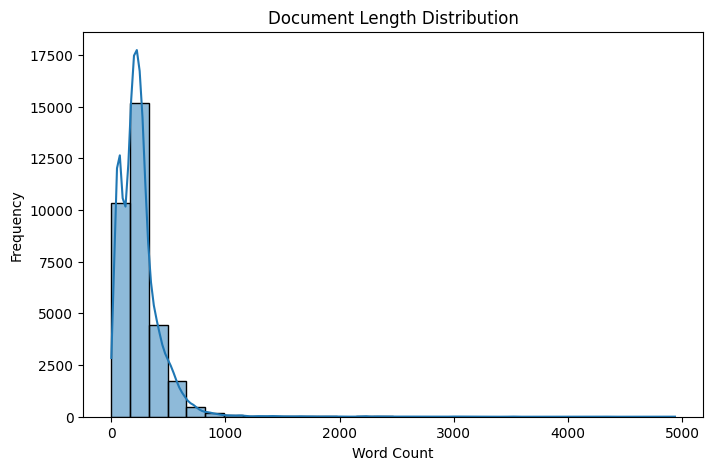

In [16]:

# Plotting document length distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title("Document Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


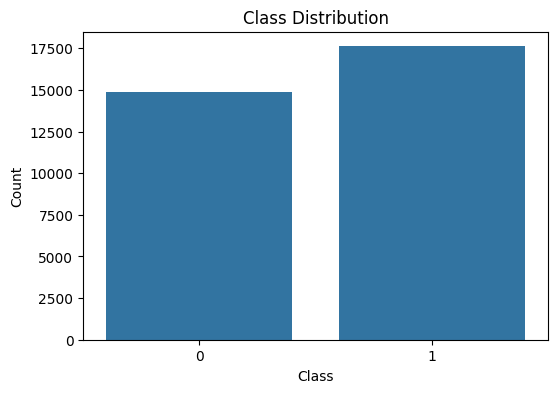

In [17]:
# Plotting class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df["binary_label"], data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

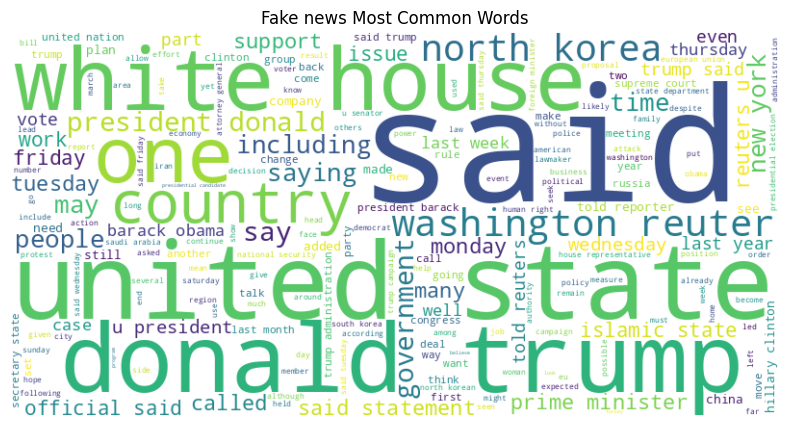

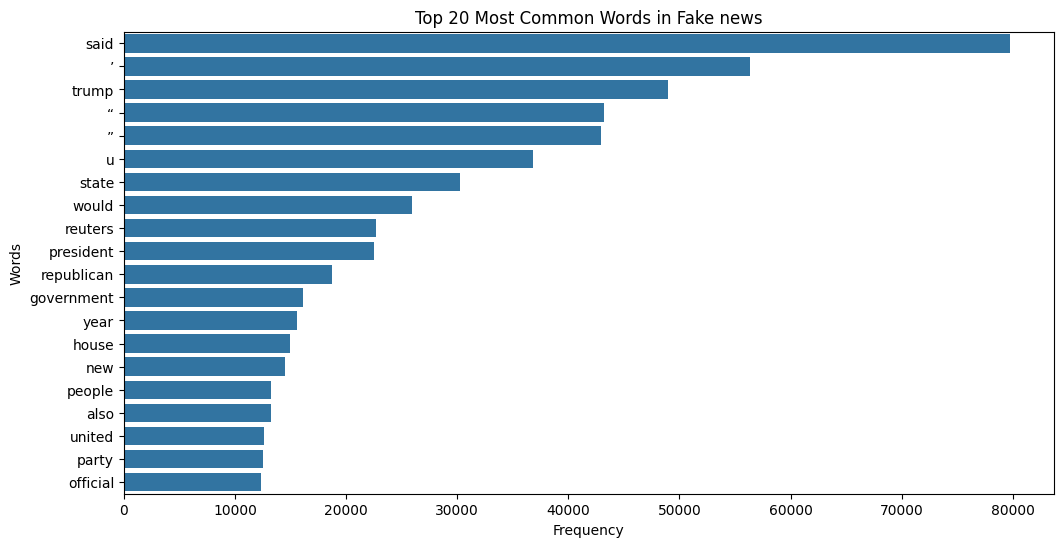

In [18]:
word_freq = Counter(fake_tokens)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(fake_tokens))

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Fake news Most Common Words")
plt.show()

# Display top 20 most common words
top_words = word_freq.most_common(20)
word_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])

# Plot most frequent words
plt.figure(figsize=(12, 6))
sns.barplot(x="Frequency", y="Word", data=word_df)
plt.title("Top 20 Most Common Words in Fake news")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

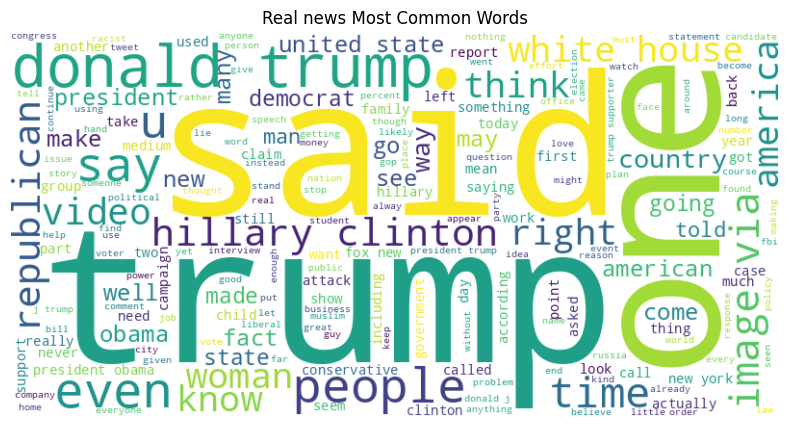

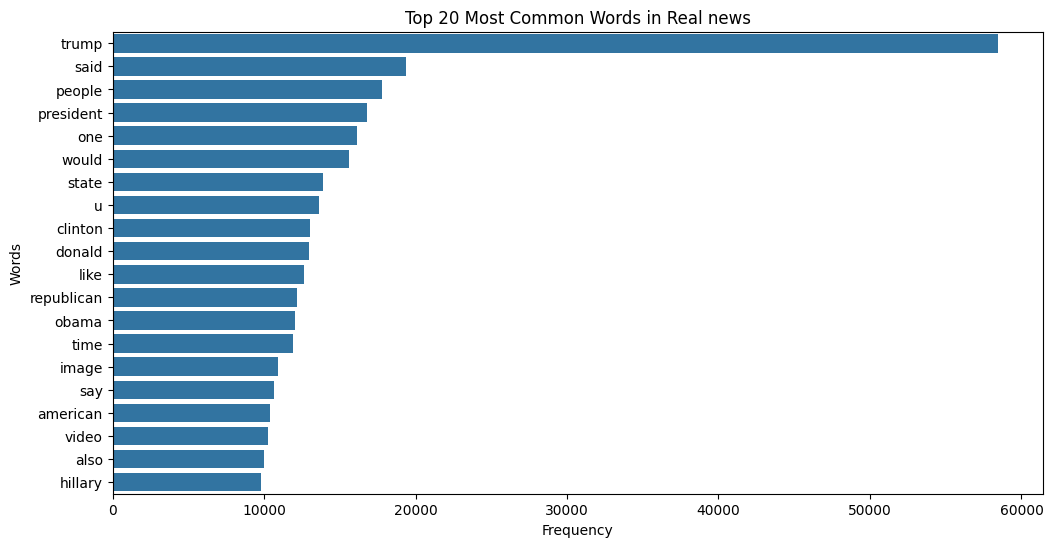

In [19]:
word_freq = Counter(real_tokens)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(real_tokens))

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Real news Most Common Words")
plt.show()

# Display top 20 most common words
top_words = word_freq.most_common(20)
word_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])

# Plot most frequent words
plt.figure(figsize=(12, 6))
sns.barplot(x="Frequency", y="Word", data=word_df)
plt.title("Top 20 Most Common Words in Real news")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

In [20]:
# manual cleanup
del df
del avg_length
del fake_tokens
del real_tokens
del fake_vocab
del real_vocab
del combined_vocab
del word_freq
del wordcloud
del top_words
del word_df
del class_counts
gc.collect()

12609

## 5. Utilities implementation

In [21]:
def evaluation_metrics(
    y_true, y_pred, y_proba=None, title=None, labels=["real", "fake"]
):
    """
    Prints out classification metrics (Precision, Recall, F1-score) 
    and confusion matrix for a given set of predictions.

    Parameters
    ----------
    y_true : array-like
        True labels for test set (0 => real, 1 => fake).
    y_pred : array-like
        Predicted labels (0 => real, 1 => fake).
    y_proba : array-like, optional
        Predicted probabilities (or decision function values) 
        for the positive class. Used to compute ROC-AUC and PR-AUC.
    title : str, optional
        A title to display with the metrics.
    labels : list of str
        The class labels in order. Default is ["real", "fake"].
    """
    print(f"\n{title}")
    # Print classification report (precision, recall, f1-score, support)
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))

    # Display confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.title(title)
    plt.show()

    # If probabilities are given, also show ROC-AUC and PR-AUC
    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC: {pr_auc:.4f}")
    print("\n")


def clear_gpu_cache():
    """ Clears GPU cache
    """
    with torch.no_grad():
        torch.cuda.empty_cache()



In [22]:


class KAFNData:
    def __init__(
        self,
        csv_path,
        random_state=42,
        fraction_fake_labeled=0.3,
        test_size=0.2,
    ):
        self.fraction_fake_labeled = fraction_fake_labeled
        df = pd.read_csv(csv_path, on_bad_lines="skip")

        train_df, test_df = train_test_split(
            df,
            test_size=test_size,
            stratify=df["binary_label"],
            random_state=random_state,
        )
        self.df_all = pd.concat([train_df, test_df], ignore_index=True)
        self.df_all["split"] = "test"
        self.df_all.loc[self.df_all.index[: len(train_df)], "split"] = "train"
        self.num_docs = len(self.df_all)

        self.df_all["pu_label"] = -1

        train_fake_inds = self.df_all.index[
            (self.df_all["split"] == "train") & (self.df_all["binary_label"] == 1)
        ].tolist()
        n_label = int(fraction_fake_labeled * len(train_fake_inds))
        if n_label < 1 and len(train_fake_inds) > 0:
            n_label = 1
        if len(train_fake_inds) > 0:
            labeled_inds = np.random.choice(
                train_fake_inds, size=n_label, replace=False
            )
            self.df_all.loc[labeled_inds, "pu_label"] = 1

    def get_doc_text(self, idx):
        return self.df_all.iloc[idx]["full_text"]

    def get_pu_label(self, idx):
        return self.df_all.iloc[idx]["pu_label"]

    def get_binary_label(self, idx):
        return self.df_all.iloc[idx]["binary_label"]

    def is_train_doc(self, idx):
        return self.df_all.iloc[idx]["split"] == "train"

    def is_test_doc(self, idx):
        return self.df_all.iloc[idx]["split"] == "test"


def baseline(data: KAFNData):

    train_df = data.df_all[data.df_all["split"] == "train"]
    X_tr = train_df["full_text"]
    y_tr = train_df["pu_label"].apply(lambda x: 1 if x == 1 else 0)

    test_df = data.df_all[data.df_all["split"] == "test"]
    X_tst = test_df["full_text"]
    y_tst = test_df["binary_label"]

    pipeline = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english",
                    max_features=5000, 
                    ngram_range=(1, 2), 
                ),
            ),
            (
                "classifier",
                MultinomialNB(
                    class_prior=[0.5, 0.5]
                ), 
            ),
        ]
    )
    pipeline.fit(X_tr, y_tr)
    y_pr = pipeline.predict(X_tst)

    proba = pipeline.predict_proba(X_tst)
    y_proba = proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]

    title = f"=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(y_tst, y_pr, y_proba, title=title)



class Doc2VecEmb:
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=20, workers=4):

        self.model = None
        self.vsize = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.workers = workers

    def train(self, data: KAFNData):
        docs = []
        for i in range(data.num_docs):
            tokens = word_tokenize(data.get_doc_text(i).lower())
            docs.append(TaggedDocument(tokens, [i]))

        model = Doc2Vec(
            documents=docs,
            vector_size=self.vsize,
            window=self.window,
            min_count=self.min_count,
            epochs=self.epochs,
            workers=self.workers,
        )
        self.model = model

    def get_vector(self, i):
        return self.model.dv[i]


class TFIDFEmb:

    def __init__(
        self, max_features=10000, ngram_range=(1, 1), min_df=1, stop_words="english"
    ):
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            stop_words=stop_words,
        )
        self.doc_vectors = None 

    def train(self, data):
        texts = [data.get_doc_text(i) for i in range(data.num_docs)]
        tfidf_matrix = self.vectorizer.fit_transform(
            texts
        )  
        self.doc_vectors = tfidf_matrix.toarray()

    def get_vector(self, i):
        return self.doc_vectors[i]


def build_doc_graph(data: KAFNData, emb_model: Doc2VecEmb, k=5):
    N = data.num_docs
    all_emb = np.array([emb_model.get_vector(i) for i in range(N)])
    sim = cosine_similarity(all_emb)

    G = nx.Graph()
    for i in range(N):
        G.add_node(i, node_type="doc")

    for i in range(N):
        row = sim[i].copy()
        row[i] = -999 
        nbrs = np.argsort(row)[::-1][:k]
        for n in nbrs:
            G.add_edge(i, n, weight=sim[i, n])
            G.add_edge(n, i, weight=sim[i, n])

    for i in range(N):
        neighbors = list(G.neighbors(i))
        total_w = sum(G[i][nb]["weight"] for nb in neighbors)
        if total_w > 0:
            for nb in neighbors:
                old_w = G[i][nb]["weight"]
                G[i][nb]["weight"] = old_w / total_w
    return G



def compute_katz_matrix(G, alpha=0.01):
    nodes = sorted(G.nodes())
    N = len(nodes)
    A = np.zeros((N, N), dtype=float)
    idx_map = {n: i for i, n in enumerate(nodes)}
    for u, v, data_e in G.edges(data=True):
        A[idx_map[u], idx_map[v]] = data_e["weight"]

    I = np.eye(N)
    try:
        mat = fractional_matrix_power(I - alpha * A, -1) - I
        return mat, idx_map
    except np.linalg.LinAlgError:
        print("Katz inversion failed.")
        return None, idx_map


def iterative_pu_lp(katz_mat, idx_map, pos_indices, unl_indices, m_iter=3, lam=1.0):

    pos_set = set(pos_indices)
    unl_set = set(unl_indices)

    R_I_tot = set()
    R_N_tot = set()

    def mean_sim(u_id, pos_ids):
        if not pos_ids:
            return 0.0
        row_u = idx_map[u_id]
        sims = [katz_mat[row_u, idx_map[p_id]] for p_id in pos_ids]
        return np.mean(sims) if len(sims) > 0 else 0.0

    for _ in range(m_iter):
        subset_size = int((lam / m_iter) * len(pos_set))
        if subset_size < 1 and len(pos_set) > 0:
            subset_size = 1
        unl_scores = [(u, mean_sim(u, pos_set)) for u in unl_set]
        unl_scores.sort(key=lambda x: x[1], reverse=True)
        R_I_prime = [x[0] for x in unl_scores[:subset_size]]
        for r in R_I_prime:
            unl_set.remove(r)
        R_I_tot.update(R_I_prime)
        pos_set.update(R_I_prime)
        unl_scores2 = [(u, mean_sim(u, pos_set)) for u in unl_set]
        unl_scores2.sort(key=lambda x: x[1])
        R_N_prime = [x[0] for x in unl_scores2[:subset_size]]
        for r in R_N_prime:
            unl_set.remove(r)
        R_N_tot.update(R_N_prime)

    return list(R_I_tot), list(R_N_tot), list(unl_set)

def extract_yake_keywords(text, top_k, yake_lan, yake_n, yake_dedup_lim):
    extractor = yake.KeywordExtractor(lan=yake_lan, n=yake_n, dedupLim=yake_dedup_lim)
    kw = extractor.extract_keywords(text)
    kw.sort(key=lambda x: x[1])  
    return kw[:top_k]


def build_doc_term_edges(
    G_doc,
    data: KAFNData,
    top_k=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=32,
):
    N = data.num_docs
    H = nx.Graph()

    for i in range(N):
        H.add_node(i, node_type="doc")

    for u, v, d in G_doc.edges(data=True):
        H.add_edge(u, v, weight=d["weight"])

    all_texts = [data.get_doc_text(i) for i in range(N)]
    parallel = Parallel(
        n_jobs=n_jobs, backend="loky"
    ) 

    all_kw_lists = parallel(
        delayed(extract_yake_keywords)(text, top_k, yake_lan, yake_n, yake_dedup_lim)
        for text in all_texts
    )

    term_usage = {}
    raw_doc_terms = [[] for _ in range(N)]
    for i, kw in enumerate(all_kw_lists):
        for ts, sc in kw:
            raw_doc_terms[i].append((ts, sc))
            term_usage.setdefault(ts, set()).add(i)
    valid_terms = {t for t, used_by in term_usage.items() if len(used_by) >= 2}
    next_id = N
    term_map = {}
    for t in valid_terms:
        term_map[t] = next_id
        H.add_node(next_id, node_type="term")
        next_id += 1

    for i in range(N):
        doc_term_list = []
        for ts, sc in raw_doc_terms[i]:
            if ts not in valid_terms:
                continue
            if sc > 1:
                w_val = 0.0
            else:
                w_val = sc * (1 - (1 / (1 + sc)))
            if w_val > 0:
                doc_term_list.append((ts, w_val))

        denom = sum(x[1] for x in doc_term_list)
        if denom > 0:
            for ts, w in doc_term_list:
                norm_w = w / denom
                tid = term_map[ts]
                H.add_edge(i, tid, weight=norm_w)
                H.add_edge(tid, i, weight=norm_w)

    for node in H.nodes():
        node_type = H.nodes[node]["node_type"]
        neighbors = list(H.neighbors(node))
        total_w = sum(H[node][nb]["weight"] for nb in neighbors)
        if total_w > 0:
            for nb in neighbors:
                H[node][nb]["weight"] /= total_w

    return H


def nx_to_heterodata(H, R_I, R_N, pos_indices, embed_dim=100):
    docs, terms = [], []
    for n, dattr in H.nodes(data=True):
        if dattr["node_type"] == "doc":
            docs.append(n)
        else:
            terms.append(n)
    docs.sort()
    terms.sort()

    doc_label_arr = []
    pos_set = set(pos_indices)
    R_I_set = set(R_I)
    R_N_set = set(R_N)
    for d in docs:
        if d in pos_set or d in R_I_set:
            doc_label_arr.append(1)
        elif d in R_N_set:
            doc_label_arr.append(0)
        else:
            doc_label_arr.append(-1)
    doc_label_arr = np.array(doc_label_arr)

    doc_map = {d: i for i, d in enumerate(docs)}
    term_map = {t: i for i, t in enumerate(terms)}
    doc_x = np.zeros((len(docs), embed_dim), dtype=np.float32)
    term_x = np.zeros((len(terms), embed_dim), dtype=np.float32)

    doc_doc_src, doc_doc_dst, doc_doc_attr = [], [], []
    doc_term_src, doc_term_dst, doc_term_attr = [], [], []
    term_doc_src, term_doc_dst, term_doc_attr = [], [], []

    for u, v, edat in H.edges(data=True):
        w = edat["weight"]
        ut = H.nodes[u]["node_type"]
        vt = H.nodes[v]["node_type"]
        if ut == "doc" and vt == "doc":
            doc_doc_src.append(doc_map[u])
            doc_doc_dst.append(doc_map[v])
            doc_doc_attr.append(w)
        elif ut == "doc" and vt == "term":
            doc_term_src.append(doc_map[u])
            doc_term_dst.append(term_map[v])
            doc_term_attr.append(w)
        elif ut == "term" and vt == "doc":
            term_doc_src.append(term_map[u])
            term_doc_dst.append(doc_map[v])
            term_doc_attr.append(w)

    hetero_data = HeteroData()
    hetero_data["doc"].x = torch.FloatTensor(doc_x)
    hetero_data["doc"].labels = torch.LongTensor(doc_label_arr)
    hetero_data["doc"].docs = torch.LongTensor(docs) 

    hetero_data["term"].x = torch.FloatTensor(term_x)

    hetero_data["doc", "to", "doc"].edge_index = torch.tensor(
        [doc_doc_src, doc_doc_dst], dtype=torch.long
    )
    hetero_data["doc", "to", "doc"].edge_attr = torch.FloatTensor(doc_doc_attr)

    hetero_data["doc", "to", "term"].edge_index = torch.tensor(
        [doc_term_src, doc_term_dst], dtype=torch.long
    )
    hetero_data["doc", "to", "term"].edge_attr = torch.FloatTensor(doc_term_attr)

    hetero_data["term", "to", "doc"].edge_index = torch.tensor(
        [term_doc_src, term_doc_dst], dtype=torch.long
    )
    hetero_data["term", "to", "doc"].edge_attr = torch.FloatTensor(term_doc_attr)

    return hetero_data, docs, terms


def fill_doc_embeddings(hetero_data: HeteroData, docs, data: KAFNData, emb_model):
    doc_x_list = []
    for d in docs:
        emb = emb_model.get_vector(d)
        doc_x_list.append(emb)
    doc_x_arr = np.vstack(doc_x_list).astype(np.float32)
    hetero_data["doc"].x = torch.tensor(doc_x_arr)


class HeteroGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=2, num_heads=4, dropout=0.5):
        super().__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        self.conv1 = HeteroConv(
            {
                ("doc", "to", "doc"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
                ("doc", "to", "term"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
                ("term", "to", "doc"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
            },
            aggr="sum",
        )

        self.conv2 = None
        if num_layers >= 2:
            self.conv2 = HeteroConv(
                {
                    ("doc", "to", "doc"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                    ("doc", "to", "term"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                    ("term", "to", "doc"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                },
                aggr="sum",
            )

        final_dim = hidden_dim * num_heads if self.conv2 else hidden_dim * num_heads
        self.classify = nn.Linear(final_dim, 1)

    def forward(self, data: HeteroData):
        x_dict, edge_index_dict, edge_attr_dict = (
            data.x_dict,
            data.edge_index_dict,
            data.edge_attr_dict,
        )

        out1 = self.conv1(x_dict, edge_index_dict, edge_attr_dict)
        for nt in out1:
            out1[nt] = F.elu(out1[nt])
            out1[nt] = F.dropout(out1[nt], p=self.dropout, training=self.training)

        if self.conv2 is not None:
            out2 = self.conv2(out1, edge_index_dict, edge_attr_dict)
            for nt in out2:
                out2[nt] = F.elu(out2[nt])
                out2[nt] = F.dropout(out2[nt], p=self.dropout, training=self.training)
            doc_logits = self.classify(out2["doc"]).squeeze(-1)
            return out2, doc_logits
        else:
            doc_logits = self.classify(out1["doc"]).squeeze(-1)
            return out1, doc_logits

def kafn_pulp_pipeline(
    data: KAFNData,
    embed_dim=100,
    doc2vec_window=5,
    doc2vec_min_count=2,
    doc2vec_epochs=20,
    doc2vec_workers=os.cpu_count(),
    k=5, 
    alpha_katz=0.01,
    m_iter=3, 
    m_factor=1.0, 
    top_yake=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=os.cpu_count(),
    gat_hidden_dim=64,
    gat_num_layers=2,
    gat_num_heads=4,
    gat_dropout=0.5,
    num_epochs=30,
    lr=1e-3,
    weight_decay=1e-4, 
    device="cpu",
):
    print("=== Training Doc2Vec ===")
    emb_model = Doc2VecEmb(
        vector_size=embed_dim,
        window=doc2vec_window,
        min_count=doc2vec_min_count,
        epochs=doc2vec_epochs,
        workers=doc2vec_workers,
    )
    emb_model.train(data)

    print("=== Building doc-doc graph ===")
    G_doc = build_doc_graph(data, emb_model, k=k)

    print("=== Computing Katz matrix ===")
    katz_mat, idx_map = compute_katz_matrix(G_doc, alpha=alpha_katz)
    if katz_mat is None:
        print("Katz failed, aborting.")
        return
    pos_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == 1]
    unl_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == -1]

    print("=== Iterative PU Label Propagation ===")
    R_I, R_N, leftover = iterative_pu_lp(
        katz_mat, idx_map, pos_indices, unl_indices, m_iter=m_iter, lam=m_factor
    )
    R_I = set(R_I)
    R_N = set(R_N)
    print(f"  => Found R_I={len(R_I)}, R_N={len(R_N)}, leftover={len(leftover)}")

    print("=== Building doc-term edges ===")
    H_all = build_doc_term_edges(
        G_doc,
        data,
        top_k=top_yake,
        yake_lan=yake_lan,
        yake_n=yake_n,
        yake_dedup_lim=yake_dedup_lim,
        n_jobs=n_jobs,
    )

    print("=== Converting Nx -> HeteroData ===")
    hetero_data, doc_ids, term_ids = nx_to_heterodata(
        H_all, R_I, R_N, pos_indices, embed_dim=embed_dim
    )

    print("=== Filling doc embeddings ===")
    fill_doc_embeddings(hetero_data, doc_ids, data, emb_model)

    device_ = torch.device(
        device if torch.cuda.is_available() or device == "cpu" else "cpu"
    )
    hetero_data = hetero_data.to(device_)

    print("=== Building Multi-Layer HeteroGAT model ===")
    in_dim = hetero_data["doc"].x.size(1)
    model = HeteroGAT(
        in_dim=in_dim,
        hidden_dim=gat_hidden_dim,
        num_layers=gat_num_layers,
        num_heads=gat_num_heads,
        dropout=gat_dropout,
    ).to(device_)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    doc_labels = hetero_data["doc"].labels  # [num_docs]
    labeled_mask = doc_labels >= 0
    labeled_y = doc_labels[labeled_mask].float().to(device_)

    print("=== Training ===")
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        _, doc_logits = model(hetero_data)
        doc_logits_labeled = doc_logits[labeled_mask]
        loss = criterion(doc_logits_labeled, labeled_y)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}")

    print("=== Evaluation on test set ===")
    model.eval()
    with torch.no_grad():
        _, doc_logits = model(hetero_data)
        preds = (doc_logits.sigmoid() > 0.5).long().cpu().numpy()

    test_docs = []
    test_true = []
    test_pred = []
    for i, did in enumerate(doc_ids):
        if data.is_test_doc(did):
            test_docs.append(did)
            true_lbl = data.get_binary_label(did)
            pred_lbl = preds[i]
            test_true.append(true_lbl)
            test_pred.append(pred_lbl)

    title = f"\n=== Keywords attention PU-LP with Doc2Vec, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(test_true, test_pred, title=title)


def kafn_pulp_pipeline_tfidf(
    data: KAFNData,
    max_features=10000,
    ngram_range=(1, 1),
    min_df=2,
    stop_words="english",
    k=5,  
    alpha_katz=0.01,  
    m_iter=3,  
    m_factor=1.0,  
    top_yake=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=os.cpu_count(),
    gat_hidden_dim=64,
    gat_num_layers=2,
    gat_num_heads=4,
    gat_dropout=0.5,
    num_epochs=30,
    lr=1e-3,
    weight_decay=1e-4,
    device="cpu",
):
    print("=== Computing TF-IDF ===")
    tfidf_model = TFIDFEmb(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=min_df,
        stop_words=stop_words,
    )
    tfidf_model.train(data)

    print("=== Building doc-doc graph ===")
    G_doc = build_doc_graph(
        data, tfidf_model, k=k
    )  

    print("=== Computing Katz matrix ===")
    katz_mat, idx_map = compute_katz_matrix(G_doc, alpha=alpha_katz)
    if katz_mat is None:
        print("Katz failed, aborting.")
        return

    pos_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == 1]
    unl_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == -1]

    print("=== Iterative PU Label Propagation ===")
    R_I, R_N, leftover = iterative_pu_lp(
        katz_mat, idx_map, pos_indices, unl_indices, m_iter=m_iter, lam=m_factor
    )
    R_I = set(R_I)
    R_N = set(R_N)
    print(f"  => Found R_I={len(R_I)}, R_N={len(R_N)}, leftover={len(leftover)}")

    print("=== Building doc-term edges ===")
    H_all = build_doc_term_edges(
        G_doc,
        data,
        top_k=top_yake,
        yake_lan=yake_lan,
        yake_n=yake_n,
        yake_dedup_lim=yake_dedup_lim,
        n_jobs=n_jobs,
    )

    print("=== Converting Nx -> HeteroData ===")
    hetero_data, doc_ids, term_ids = nx_to_heterodata(
        H_all,
        R_I,
        R_N,
        pos_indices,
        embed_dim=tfidf_model.doc_vectors.shape[1],
    )
    
    print("=== Filling doc embeddings ===")
    doc_x_list = []
    for d in doc_ids:
        emb = tfidf_model.get_vector(d)
        doc_x_list.append(emb)
    doc_x_arr = np.vstack(doc_x_list).astype(np.float32)
    hetero_data["doc"].x = torch.tensor(doc_x_arr)
    device_ = torch.device(
        device if torch.cuda.is_available() or device == "cpu" else "cpu"
    )
    hetero_data = hetero_data.to(device_)

    print("=== Building Multi-Layer HeteroGAT model ===")
    in_dim = hetero_data["doc"].x.size(1) 
    model = HeteroGAT(
        in_dim=in_dim,
        hidden_dim=gat_hidden_dim,
        num_layers=gat_num_layers,
        num_heads=gat_num_heads,
        dropout=gat_dropout,
    ).to(device_)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    doc_labels = hetero_data["doc"].labels
    labeled_mask = doc_labels >= 0
    labeled_y = doc_labels[labeled_mask].float().to(device_)

    print("=== Training ===")
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        _, doc_logits = model(hetero_data)
        doc_logits_labeled = doc_logits[labeled_mask]
        loss = criterion(doc_logits_labeled, labeled_y)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}")

    print("=== Evaluation on test set ===")
    model.eval()
    with torch.no_grad():
        _, doc_logits = model(hetero_data)
        preds = (doc_logits.sigmoid() > 0.5).long().cpu().numpy()

    test_docs = []
    test_true = []
    test_pred = []
    for i, did in enumerate(doc_ids):
        if data.is_test_doc(did):
            test_docs.append(did)
            test_true.append(data.get_binary_label(did))
            test_pred.append(preds[i])

    title = f"\n=== Keywords attention PU-LP with TFIDF, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(test_true, test_pred, title=title)


def test_baseline(data: KAFNData):
    baseline(data)
    clear_gpu_cache()
    


def test_pulp_doc2vec_pipeline(data: KAFNData):
    kafn_pulp_pipeline(
        data,
        embed_dim=100,
        doc2vec_window=5,
        doc2vec_min_count=2,
        doc2vec_epochs=30,
        doc2vec_workers=os.cpu_count(),
     
        k=5,
        alpha_katz=0.02, 
        m_iter=3,
        m_factor=1.0,

        top_yake=5,
        yake_lan="en",
        yake_n=1,  
        yake_dedup_lim=0.9,
        n_jobs=os.cpu_count(),

        gat_hidden_dim=64,  
        gat_num_layers=2,
        gat_num_heads=2,  
        gat_dropout=0.5,
  
        num_epochs=50,
        lr=1e-3,
        weight_decay=1e-4,
        device="cuda",
    )
    clear_gpu_cache()


def test_pulp_tfidfvectorizer_pipeline(data: KAFNData):
    kafn_pulp_pipeline_tfidf(
        data,
        max_features=5000,
        ngram_range=(1, 3),
        min_df=2,
        stop_words="english",
        k=5,
        alpha_katz=0.02,
        m_iter=3,
        m_factor=1.0,
        top_yake=5,
        yake_lan="en",
        yake_n=1,
        yake_dedup_lim=0.9,
        n_jobs=os.cpu_count(),
        gat_hidden_dim=64,
        gat_num_layers=2,
        gat_num_heads=4,
        gat_dropout=0.5,
        num_epochs=30,
        lr=1e-3,
        weight_decay=1e-4,
        device="cuda",
    )
    clear_gpu_cache()




=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.3 ===
              precision    recall  f1-score   support

        real     0.8203    0.9754    0.8912      2972
        fake     0.9753    0.8197    0.8908      3522

    accuracy                         0.8910      6494
   macro avg     0.8978    0.8976    0.8910      6494
weighted avg     0.9044    0.8910    0.8910      6494



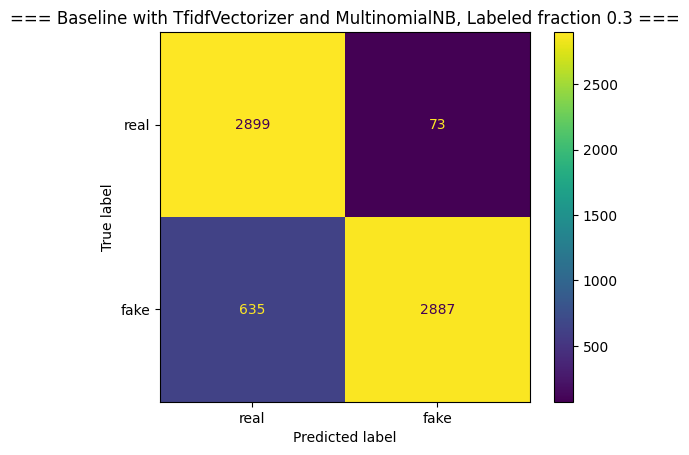

ROC-AUC: 0.9723
PR-AUC: 0.9768


=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=5790, R_N=5790, leftover=16664
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.5675
Epoch 20/50 - Loss: 0.5397
Epoch 30/50 - Loss: 0.5201
Epoch 40/50 - Loss: 0.5112
Epoch 50/50 - Loss: 0.4999
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.3 ===
              precision    recall  f1-score   support

        real     0.9176    0.9367    0.9271      2972
        fake     0.9457    0.9290    0.9373      3522

    accuracy                         0.9326      6494
   macro avg     0.9316    0.9329    0.9322      6494
weighted avg     0.9328    0.9326    0.9326      6494



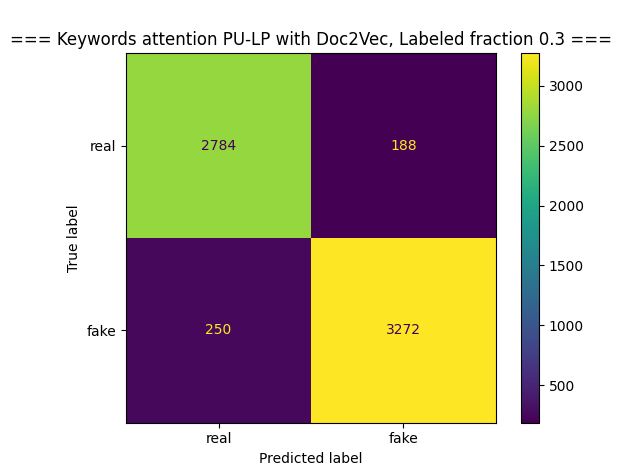

In [23]:

dataset_file = "data/processed.csv"
# fraction = [0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1]
fraction = [0.3]


for fraction in fraction:
    data = KAFNData(
        csv_path=dataset_file, random_state=42, fraction_fake_labeled=fraction, test_size=0.2
    )
    test_baseline(data)
    # test_pulp_tfidfvectorizer_pipeline(data)
    test_pulp_doc2vec_pipeline(data)
    del data
    gc.collect()